# Exploratory Data Analysis and Preprocessing  
## Indian Liver Patient Dataset (ILPD)

This notebook performs preprocessing and exploratory data analysis on the Indian Liver Patient Dataset (ILPD) for multivariate medical classification.  

The objective is to:
- Clean and prepare the dataset
- Analyze feature distributions
- Detect outliers and skewness
- Examine class imbalance
- Study feature correlations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

## 1. Dataset Loading

The dataset is loaded without headers. Column names are assigned manually based on dataset documentation.

In [2]:
df = pd.read_csv("D:/IDEAS Project/data/Indian Liver Patient Dataset (ILPD).csv",header=None)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("Class distribution:")
print(df.iloc[:, -1].value_counts())

Shape: (583, 11)

First 5 rows:
   0       1     2    3    4   5    6    7    8     9   10
0  65  Female   0.7  0.1  187  16   18  6.8  3.3  0.90   1
1  62    Male  10.9  5.5  699  64  100  7.5  3.2  0.74   1
2  62    Male   7.3  4.1  490  60   68  7.0  3.3  0.89   1
3  58    Male   1.0  0.4  182  14   20  6.8  3.4  1.00   1
4  72    Male   3.9  2.0  195  27   59  7.3  2.4  0.40   1
Class distribution:
10
1    416
2    167
Name: count, dtype: int64


### Features in the Dataset

- **Age** – Age of the patient  
- **Gender** – Gender of the patient (Male/Female)  
- **Total Bilirubin** – Total bilirubin level in blood  
- **Direct Bilirubin** – Direct bilirubin level  
- **Alkaline Phosphotase** – Enzyme related to liver and bone health  
- **Alamine Aminotransferase (ALT)** – Liver enzyme level  
- **Aspartate Aminotransferase (AST)** – Liver enzyme level  
- **Total Proteins** – Total protein level in blood  
- **Albumin** – Albumin protein level  
- **Albumin and Globulin Ratio** – Ratio between albumin and globulin proteins  
- **Dataset** – Target variable indicating whether the patient has liver disease

In [3]:
df.columns = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_Globulin_Ratio",
    "Target"
]
print(df.head())

   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65  Female              0.7               0.1                   187   
1   62    Male             10.9               5.5                   699   
2   62    Male              7.3               4.1                   490   
3   58    Male              1.0               0.4                   182   
4   72    Male              3.9               2.0                   195   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Proteins  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                          59             7.3   

   Albumin  Albumin_Globulin_Ratio  Target  
0      3.3                    0.90       1  
1      3

## Data Type Verification

Ensuring that each column has the correct data type is important for proper analysis. Numerical columns should be stored as numeric data types, while categorical columns should be properly encoded.

This step verifies the data types of each feature in the dataset.

In [4]:
print("Checking expected data types")
print("Gender dtype:", df["Gender"].dtype)
numeric_columns = df.drop(columns=["Gender"]).columns
for col in numeric_columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        print("Non-numeric column found:", col)
        df[col] = pd.to_numeric(df[col], errors="coerce")

Checking expected data types
Gender dtype: str


## 2. Initial Data Inspection

This section examines:
- Data types of each feature
- Presence of missing values

In [5]:
print(df.dtypes)

Age                             int64
Gender                            str
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Proteins                float64
Albumin                       float64
Albumin_Globulin_Ratio        float64
Target                          int64
dtype: object


### 2.1 Missing Value Analysis

We check for missing values across all features.  


In [6]:
print(df.isnull().sum())

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
Albumin_Globulin_Ratio        4
Target                        0
dtype: int64


In the dataset, the `Albumin_Globulin_Ratio` column contains missing entries.

In [7]:
df["Albumin_Globulin_Ratio"].nunique()

69

### 2.2 Handling Missing Values

Since the number of missing values is small, rows containing missing values are removed to ensure statistical consistency.

In [8]:
df=df.dropna()

## Detecting Infinite and Invalid Values

Invalid values in a dataset can lead to incorrect analysis and unreliable model predictions. These values may occur due to data entry errors, incorrect measurements, or inconsistencies in the dataset.

In this step, the dataset is examined to identify any invalid or unusual values such as negative values where they are not expected, unrealistic numerical ranges, or inconsistent categorical entries.

For numerical columns, checks are performed to detect values that fall outside expected ranges. Additionally, the dataset is inspected for special numerical values such as **infinite values (`∞` or `-∞`)** that may arise during calculations.

Since the dataset may contain both numeric and non-numeric columns, only the **numeric columns** are selected before applying the infinity check. This avoids type errors when performing numerical operations.

In [9]:
invalid_checks = {
    "Age_negative": (df["Age"] < 0).sum(),
    "Age_too_high": (df["Age"] > 120).sum(),
    "Bilirubin_negative": (df["Total_Bilirubin"] < 0).sum(),
    "Proteins_negative": (df["Total_Proteins"] < 0).sum(),
    "Albumin_negative": (df["Albumin"] < 0).sum(),
    "AG_ratio_negative": (df["Albumin_Globulin_Ratio"] < 0).sum()
}
print("Invalid value checks:")
for k,v in invalid_checks.items():
    print(k,":",v)
print("Infinite values check:")
print(np.isinf(df.select_dtypes(include=[np.number])).sum())

Invalid value checks:
Age_negative : 0
Age_too_high : 0
Bilirubin_negative : 0
Proteins_negative : 0
Albumin_negative : 0
AG_ratio_negative : 0
Infinite values check:
Age                           0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Proteins                0
Albumin                       0
Albumin_Globulin_Ratio        0
Target                        0
dtype: int64


### 2.3 Encoding Categorical Variables

The `Gender` column is converted into numerical format:
- Male → 1
- Female → 0

This allows statistical computation and model compatibility.

In [10]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

### 2.4 Duplicate Detection

Duplicate records are identified and removed to avoid bias in model training.

In [11]:
duplicates = df.duplicated().sum()
print(duplicates)

13


In [12]:
df = df.drop_duplicates()

## 3. Feature and Target Separation

The dataset is divided into:
- Feature matrix (X)
- Target variable (y)

The target variable represents liver disease classification.

In [13]:
X = df.iloc[:, :-1]   
y = df.iloc[:, -1]    

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (566, 10)
Target shape: (566,)


## 4. Target Variable Analysis

This section examines class distribution to detect potential imbalance.

Class distribution:
 Target
1    404
2    162
Name: count, dtype: int64


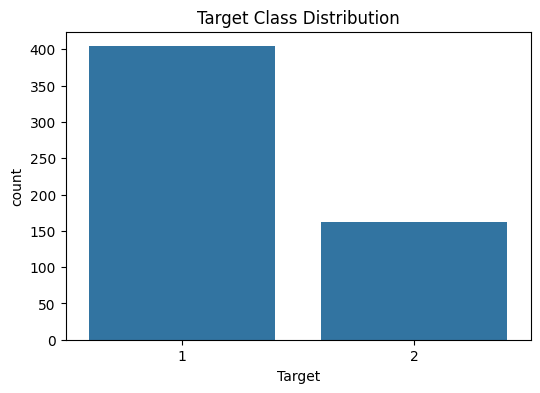

In [14]:
print("Class distribution:\n", y.value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.show()

## Feature Scaling

Feature scaling is an important preprocessing step in machine learning. It ensures that all numerical features contribute equally to the model by bringing them onto a similar scale.

Many machine learning algorithms perform better when the data is properly scaled. In this notebook, two scaling techniques are applied:

- **StandardScaler**
- **RobustScaler**

These techniques help normalize the feature values and improve model performance.

### Standard Scaling (StandardScaler)

StandardScaler is a commonly used feature scaling technique that standardizes the dataset by transforming the features so that they have a **mean of 0** and a **standard deviation of 1**.

The transformation is performed using the following formula:

Z = {X - μ}/σ

Where:

- **X** = Original feature value  
- **μ** = Mean of the feature  
- **σ** = Standard deviation of the feature  

In this step, the **StandardScaler** from the Scikit-learn library is used to scale the numerical features of the dataset.

In [15]:
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)
X_standard = pd.DataFrame(X_standard, columns=X.columns)
print("Standard scaled dataset preview")
print(X_standard.head())

Standard scaled dataset preview
        Age    Gender  Total_Bilirubin  Direct_Bilirubin  \
0  1.236928 -1.761093        -0.420124         -0.495190   
1  1.052432  0.567829         1.203777          1.406906   
2  1.052432  0.567829         0.630636          0.913770   
3  0.806437  0.567829        -0.372362         -0.389518   
4  1.667418  0.567829         0.089335          0.174066   

   Alkaline_Phosphotase  Alamine_Aminotransferase  Aspartate_Aminotransferase  \
0             -0.429625                 -0.352659                   -0.315148   
1              1.654054                 -0.088755                   -0.033926   
2              0.803490                 -0.110747                   -0.143671   
3             -0.449974                 -0.363655                   -0.308289   
4             -0.397068                 -0.292181                   -0.174537   

   Total_Proteins   Albumin  Albumin_Globulin_Ratio  
0        0.280819  0.194225               -0.150315  
1        0.9

### Robust Scaling (RobustScaler)

RobustScaler is a scaling technique designed to be **resistant to the influence of outliers**. Instead of using the mean and standard deviation, it uses the **median** and **interquartile range (IQR)** for scaling.

The transformation is based on:

X_{scaled} = {X - Median}/IQR

Where:

- **Median** = Middle value of the feature
- **IQR** = Interquartile range (difference between the 75th and 25th percentiles)

Because it relies on median and IQR rather than mean and standard deviation, RobustScaler performs better when the dataset contains extreme values or outliers.

In this notebook, **RobustScaler** is applied to scale the features while minimizing the impact of outliers.

In [16]:
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)
X_robust = pd.DataFrame(X_robust, columns=X.columns)
print("Robust scaled dataset preview")
print(X_robust.head())

Robust scaled dataset preview
    Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0  0.80    -1.0        -0.166667         -0.181818             -0.172131   
1  0.68     0.0         5.500000          4.727273              4.024590   
2  0.68     0.0         3.500000          3.454545              2.311475   
3  0.52     0.0         0.000000          0.090909             -0.213115   
4  1.08     0.0         1.611111          1.545455             -0.106557   

   Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Proteins  \
0                 -0.503311                   -0.370968        0.142857   
1                  0.768212                    0.951613        0.642857   
2                  0.662252                    0.435484        0.285714   
3                 -0.556291                   -0.338710        0.142857   
4                 -0.211921                    0.290323        0.500000   

    Albumin  Albumin_Globulin_Ratio  
0  0.166667             

In [17]:
X_standard.to_csv("D:/IDEAS Project/data/ILPD_standard_scaled.csv", index=False)
X_robust.to_csv("D:/IDEAS Project/data/ILPD_robust_scaled.csv", index=False)

## 5. Measures of Central Tendency

We compute:
- Mean
- Median
- Mode

These statistics help understand the central behavior of each medical parameter.

In [18]:
summary_stats = pd.DataFrame({
    "Mean": X.mean(),
    "Median": X.median(),
    "Mode": X.mode().iloc[0]
})

print(summary_stats)

                                  Mean  Median   Mode
Age                          44.886926   45.00   60.0
Gender                        0.756184    1.00    1.0
Total_Bilirubin               3.338869    1.00    0.8
Direct_Bilirubin              1.505830    0.30    0.2
Alkaline_Phosphotase        292.567138  208.00  198.0
Alamine_Aminotransferase     80.143110   35.00   25.0
Aspartate_Aminotransferase  109.892226   41.00   23.0
Total_Proteins                6.494876    6.60    7.0
Albumin                       3.145583    3.10    3.0
Albumin_Globulin_Ratio        0.948004    0.95    1.0


## 6. Distribution Analysis

We evaluate:
- Skewness (asymmetry)
- Kurtosis (tail heaviness)

In [19]:
distribution_stats = pd.DataFrame({
    "Skewness": X.apply(skew),
    "Kurtosis": X.apply(kurtosis)
})

print(distribution_stats)

                             Skewness    Kurtosis
Age                         -0.050863   -0.576138
Gender                      -1.193264   -0.576121
Total_Bilirubin              4.839575   35.931882
Direct_Bilirubin             3.165768   10.913520
Alkaline_Phosphotase         3.706683   17.073556
Alamine_Aminotransferase     6.654816   51.873353
Aspartate_Aminotransferase  10.496640  147.979316
Total_Proteins              -0.317094    0.259749
Albumin                     -0.065644   -0.383253
Albumin_Globulin_Ratio       0.998639    3.314388


## 7. Feature Distribution Visualization

Histograms are plotted to visually assess:
- Shape of distribution
- Presence of skewness
- Multi-modality
- Outliers

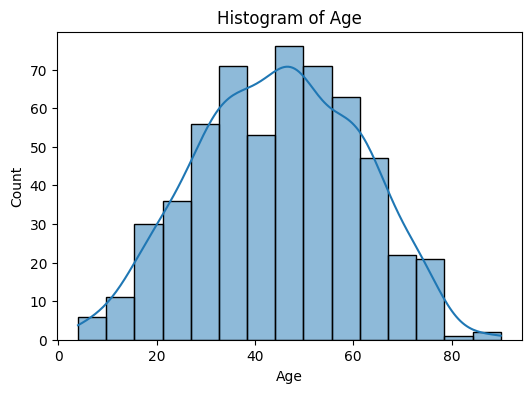

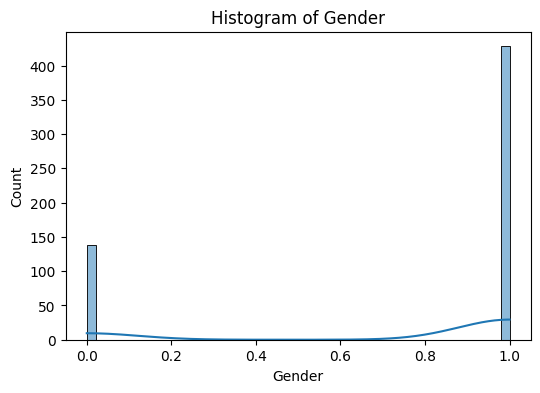

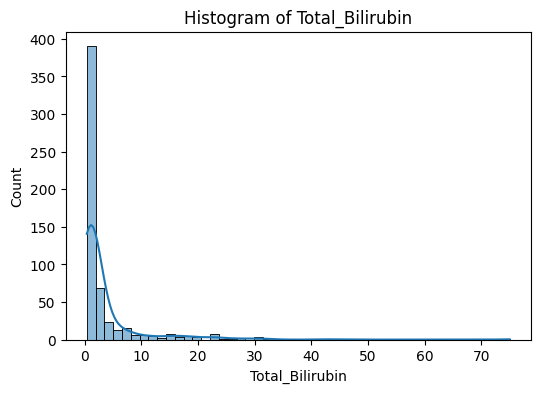

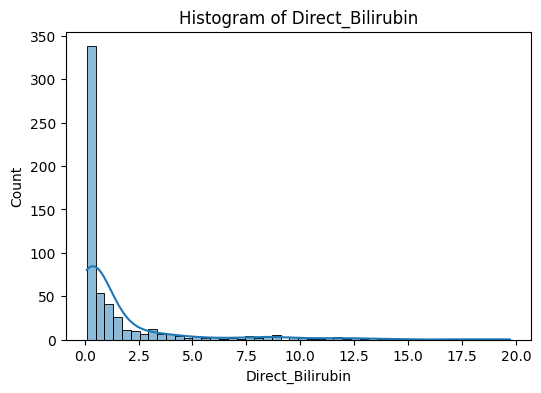

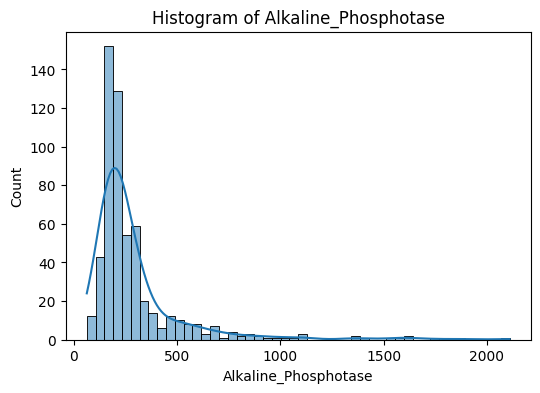

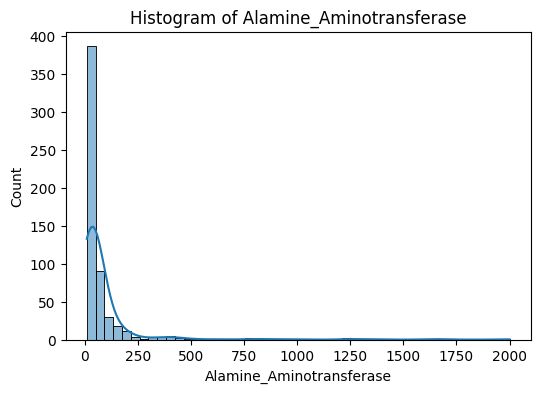

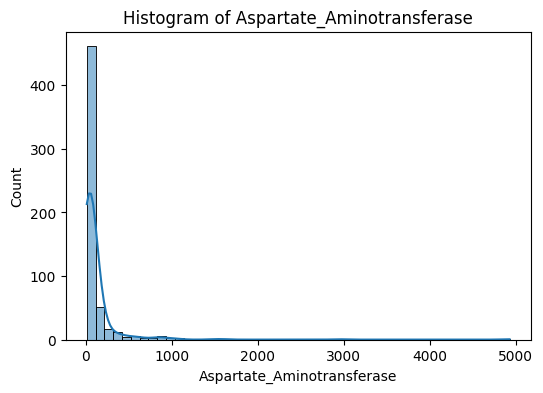

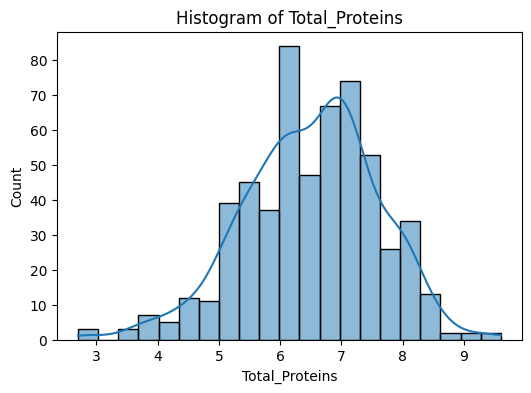

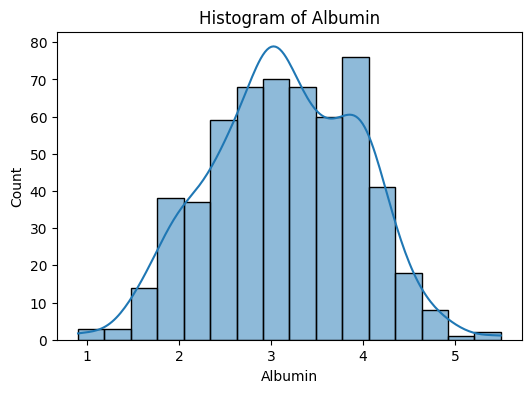

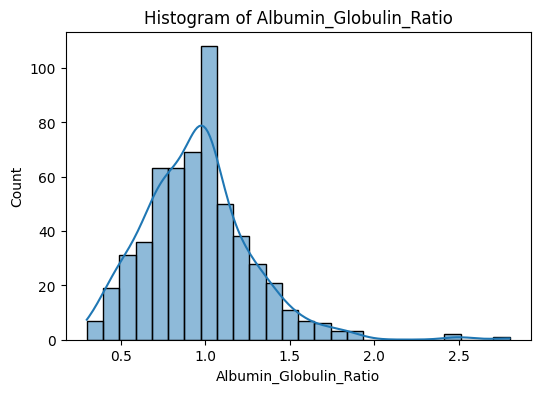

In [20]:
for col in X.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(X[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

## 8. Outlier Detection using Boxplots

Boxplots help identify:
- Interquartile range (IQR)
- Extreme observations
- Spread of medical parameters

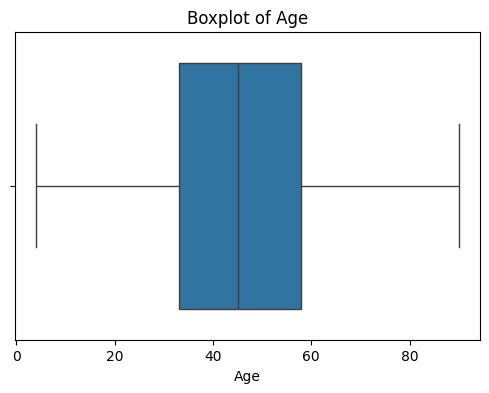

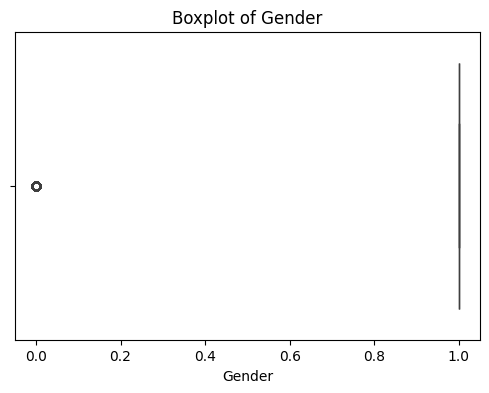

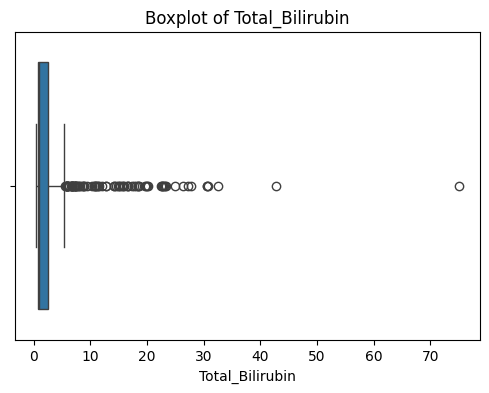

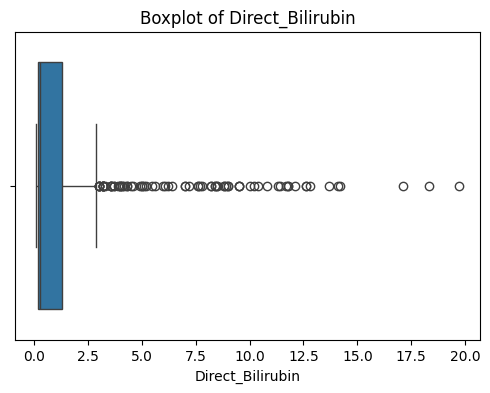

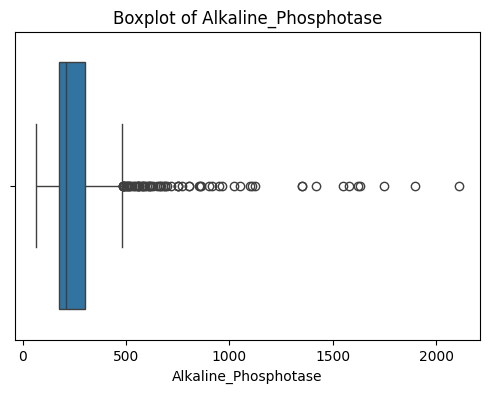

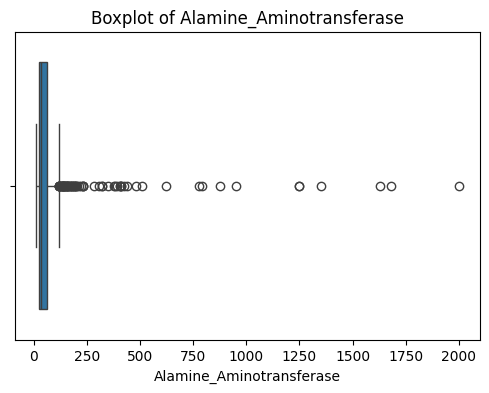

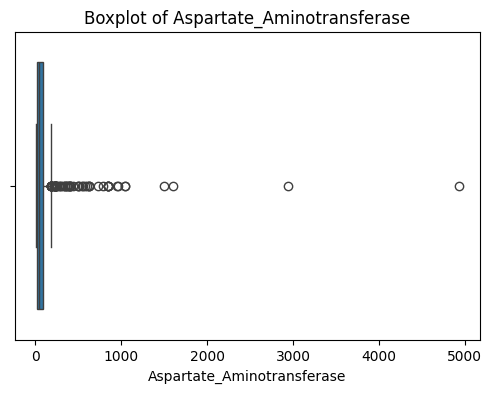

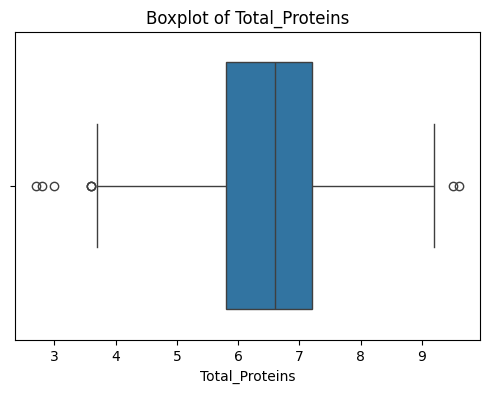

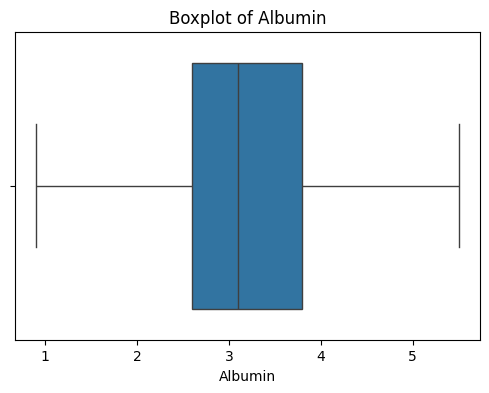

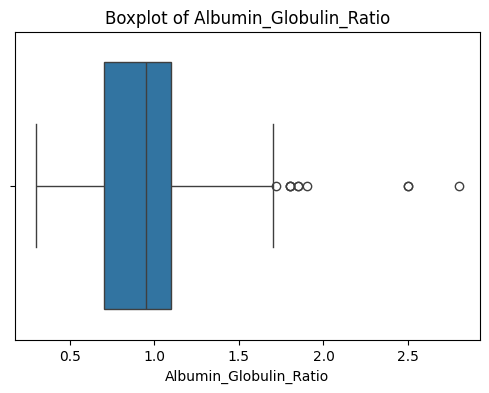

In [21]:
for col in X.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=X[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 9. Correlation Analysis

A correlation heatmap is generated to examine relationships between biochemical markers.

High correlation may indicate:
- Multicollinearity
- Related physiological processes

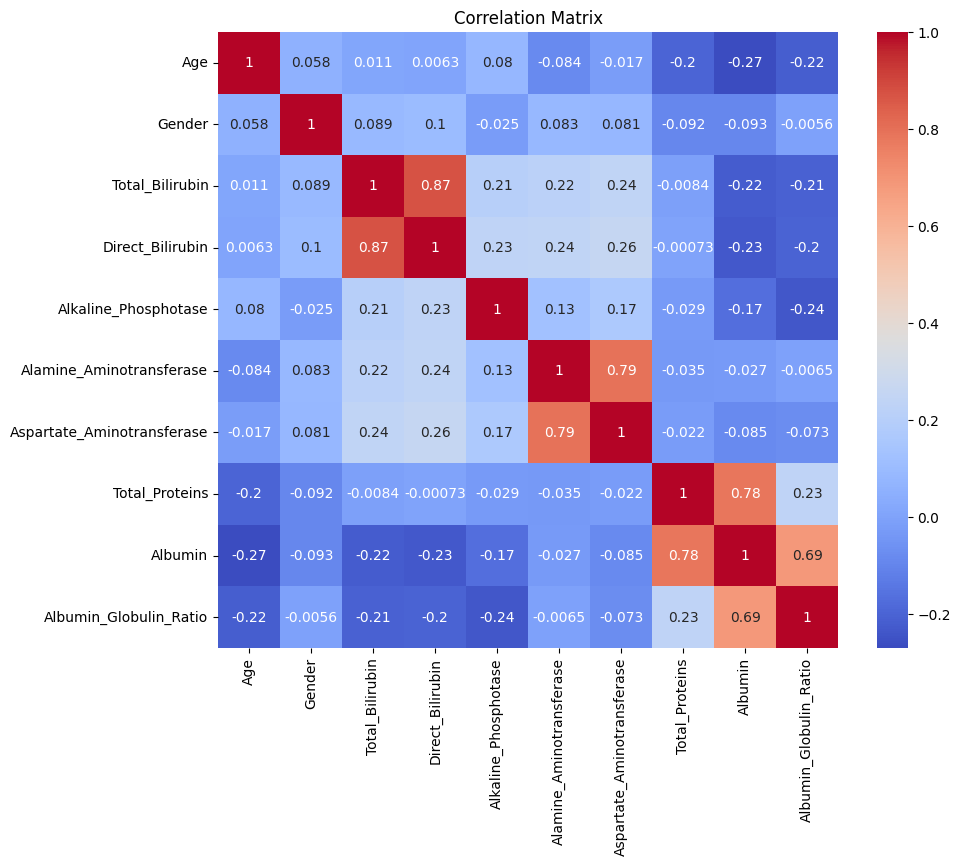

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [23]:
df.to_csv("D:/IDEAS Project/data/ILPD_preprocessed.csv", index=False)